In [ ]:
%%HTML
<style type="text/css">
table.dataframe td, table.dataframe th{border: 1px 
black solid ! important;color:black !important;}

In [ ]:
import py3Dmol;import pubchempy as pcp
gly=pcp.get_compounds(
'gly', 'name')[0]
x=py3Dmol.view(query='cid:{}'.format(
gly.cid), width=300,
height=300).setStyle({'stick': {
'radius': .05},'sphere': {'scale': 0.25}});x

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [ ]:
results = pcp.get_compounds('Gly', 'name');#print(results)

[Compound(750)]


In [ ]:
#for compound in results:
#    print(compound.isomeric_smiles)

C(C(=O)O)N


In [ ]:
nitric_acid_df = pcp.get_compounds('HNO3', 'formula', as_dataframe=True)[:3]
nitric_acid_df[['iupac_name', 'molecular_formula', 'canonical_smiles', 'inchi']]

,iupac_name,molecular_formula,canonical_smiles,inchi
cid,,,,
944,nitric acid,HNO3,[N+](=O)(O)[O-],"InChI=1S/HNO3/c2-1(3)4/h(H,2,3,4)"
123349,hydroxy nitrite,HNO3,N(=O)OO,InChI=1S/HNO3/c2-1-4-3/h3H
12025424,deuterio nitrate,HNO3,[N+](=O)(O)[O-],"InChI=1S/HNO3/c2-1(3)4/h(H,2,3,4)/i/hD"


In [ ]:
glydf= pcp.get_compounds('GLY', 'name', as_dataframe=True)[:3]
glydf[['iupac_name', 'molecular_formula', 'canonical_smiles', 'inchi']]

,iupac_name,molecular_formula,canonical_smiles,inchi
cid,,,,
750,2-aminoacetic acid,C2H5NO2,C(C(=O)O)N,"InChI=1S/C2H5NO2/c3-1-2(4)5/h1,3H2,(H,4,5)"


In [ ]:
pcp.get_compounds("InChI=1S/C2H5NO2/c3-1-2(4)5/h1,3H2,(H,4,5)","inchi",
                  as_dataframe=True).iloc[0]['iupac_name']

'2-aminoacetic acid'

In [ ]:
from chembl_webresource_client.new_client import new_client
molecule = new_client.molecule
gli = molecule.search('gly')

In [ ]:
import pypdb;#pypdb.Query('gly').search()

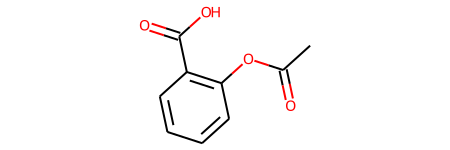

In [ ]:
from rdkit import Chem;from rdkit.Chem import Draw
compound_smiles = 'c1cc(C(=O)O)c(OC(=O)C)cc1'
m = Chem.MolFromSmiles(compound_smiles)
im=Draw.MolToImage(m)

In [ ]:
Draw.MolToFile(m,"mol.png")

In [ ]:
import pubchempy as pcp;import pandas as pd

In [ ]:
prop = pcp.get_properties(['MolecularFormula', 'MolecularWeight', 'CanonicalSMILES', 'IsomericSMILES',
'InChI', 'InChIKey', 'IUPACName'],'CN1N=C(C=C1C(F)(F)F)C1=CC=C(S1)C1=CC=NC(SCC(=O)NC2=CC=C(Cl)C=C2)=N1', 'smiles')

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDConfig
from rdkit.Chem.Draw import IPythonConsole 
from rdkit.Chem import Draw
import numpy as np
from IPython.display import display,Image

In [ ]:
from tqdm import tqdm, trange
import rdkit.Chem.Lipinski as Lipinksy

In [ ]:
def lipinsky(smiles):
    return (Lipinksy.NumHDonors(smiles),
            Lipinksy.NumHAcceptors(smiles),
            Lipinksy.rdMolDescriptors.CalcExactMolWt(smiles),
            Lipinksy.rdMolDescriptors.CalcCrippenDescriptors(smiles)[0])
def is_lipinsky(smiles, ideal=(5, 10, 500, 5)):
    return all(i < j for i, j in zip(lipinsky(smiles), ideal))

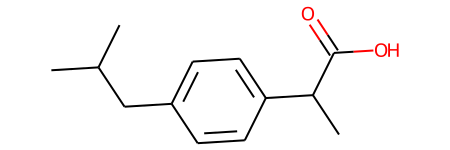

In [ ]:
ibu=Chem.MolFromSmiles('CC(C)CC1=CC=C(C=C1)C(C)C(=O)O')
AllChem.Compute2DCoords(ibu)
#display(ibu)

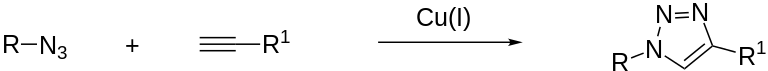

In [ ]:
#display(Image('https://upload.wikimedia.org/wikipedia/commons/thumb/6/66/CuAAC.svg/768px-CuAAC.svg.png'))

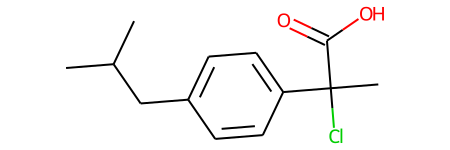

In [ ]:
cl_ibu=Chem.MolFromSmiles('CC(C)CC1=CC=C(C=C1)C(Cl)(C)C(=O)O')
AllChem.Compute2DCoords(cl_ibu)
#display(cl_ibu)#

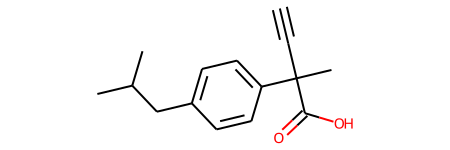

In [ ]:
al_ibu=Chem.MolFromSmiles('CC(C)CC1=CC=C(C=C1)C(C#C)(C)C(=O)O')
AllChem.Compute2DCoords(al_ibu)
#display(al_ibu)

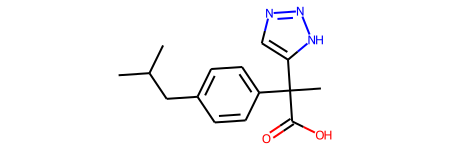

In [ ]:
al_ibu=Chem.MolFromSmiles('CC(C)CC1=CC=C(C=C1)C(C1=CN=NN1)(C)C(=O)O')
AllChem.Compute2DCoords(al_ibu)
#display(al_ibu)

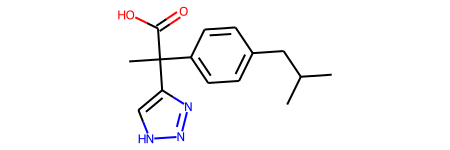

In [ ]:
template = Chem.MolFromSmiles('N1N=NC(=C1)C(C)(C(=O)O)C1=CC=C(C=C1)CC(C)C')
AllChem.Compute2DCoords(template)
#display(template)

In [ ]:
azides = [Chem.MolFromSmiles('N=[N+]=[N-]'),
          Chem.MolFromSmiles('N=[N+]=[NH]')]

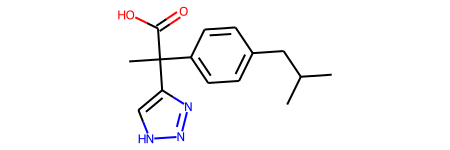

In [ ]:
template

In [ ]:
from PyBioMed.PyGetMol import Getmol
DrugBankID = 'DB01014'

In [ ]:
from PyBioMed.PyGetMol.Getmol import ReadMolFromSmile
mol = ReadMolFromSmile('N[C@@H](CO)C(=O)O')

In [ ]:
from PyBioMed.PyGetMol import GetProtein
from PyBioMed.PyGetMol import GetDNA
from PyBioMed.PyPretreat import PyPretreatPro
protein="ADGCGVGEGTGQGPMCNCMCMKWVYADEDAADLESDSFADEDASLESDSFPWSNQRVFCSFADEDASU"
#print(PyPretreatPro.ProteinCheck(protein))

0


In [ ]:
from PyBioMed.PyPretreat import PyPretreatPro
protein="ADGCRN"
#print(PyPretreatPro.ProteinCheck(protein))

6


In [ ]:
from PyBioMed.PyPretreat import PyPretreatDNA
DNA="ATTTAC"
#print(PyPretreatDNA.DNAChecks(DNA))

True


In [ ]:
DNA= "ATCGUA"
#print(PyPretreatDNA.DNAChecks(DNA))

U
